In [1]:
import sys
import argparse
import os
os.environ['KMP_DUPLICATE_LIB_OK']='True'
import numpy as np
import pandas as pd

import csv
import gzip

import scipy.io
import numpy as np 

import matplotlib
%matplotlib inline
import matplotlib.pyplot as plt
import pandas as pd
from matplotlib.pyplot import rc_context
import anndata
import torch

# --- MATPLOTLIB SETTINGS ---
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib import rc
rc_params = {
    "font.family": "sans-serif", # "text.usetex": True,
    "font.serif" : ['Arial'], # "font.size" : 6,
    "font.weight" : "normal",
    'xtick.labelsize' : 5,
    'ytick.labelsize' : 5,
    'legend.fontsize' : 5,
    'axes.labelsize' : 6,
    'axes.linewidth': 0.8,
    'lines.linewidth' : 1,
    'axes.titlesize' : 7, # figure.titlesize,
    'legend.title_fontsize' : 5
}
matplotlib.rcParams.update(rc_params)
margins = {  #     vvv margin in inches
    "left"   :     0.2,
    'right' : 1.0,
    'bottom' : 0.15
}

import helper_functions



/Users/mingyaolab/opt/anaconda3/envs/misalignment/lib/python3.10/site-packages/tqdm/auto.py:22: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:

# --- INIT ---



# which data to use
head_folder = "/".join(os.getcwd().split("/")[:3])
data_head_folder = '%s/Dropbox/aorta_circadian_data/datasets/joint' % head_folder
hvg_to_use = 'prior_knowledge_guided' # 'transformed_X_outlier_variance'
cluster_resolution = 0.05
subcluster_resolution = 0.20


# get corresponding paths
adata_path = '%s/adata_qc_filtered.h5ad' % data_head_folder
hvg_folder = '%s/data_annotations/hvg/%s' % (data_head_folder,hvg_to_use)
scvi_res_folder = '%s/scvi_res' % hvg_folder
scvi_mean_embedding_df_path = '%s/scvi_mean_embedding.tsv' % scvi_res_folder
umap_path_out = '%s/scvi_mean_umap_embedding.tsv' % scvi_res_folder

# clusters
clustering_folder = '%s/clustering/res_%s' % (scvi_res_folder, str(cluster_resolution))
cluster_df_fileout = '%s/clusters.tsv' % (clustering_folder)

# SMC clusters
subclustering_folder = '%s/subclustering/res_%s' % (clustering_folder,subcluster_resolution)
subcluster_df_fileout = '%s/smc_subclusters.tsv' % (subclustering_folder)


# settings
mesor_frac_thresh = 0.9
mesor_effect_thresh = 0.3 / np.log10(np.e)
amp_frac_thresh = 0.9
amp_effect_thresh = 0.2 / np.log10(np.e)
acrophase_frac_thresh = 0.1
acrophase_effect_thresh = 3 * (np.pi / 12.0)
frac_circadian_samples_crossing_zero_thresh = 0.1
log10_bf_thresh = 2
num_waveform_samples = 300
use_log_prop_fft = True
use_subclusters = True

# folder out
folder_out = '%s/Dropbox/aorta_circadian_data/results/fig_3' % head_folder
if use_subclusters:
    folder_out = '%s/smc_subclusters' % folder_out
if not os.path.exists(folder_out):
    os.makedirs(folder_out)


# set the cluster column
if use_subclusters:
    clustering_folder = subclustering_folder
    cluster_df_fileout = subcluster_df_fileout



In [3]:
# --- LOAD THE ADATA ---

adata = anndata.read_h5ad(adata_path)

adata



AnnData object with n_obs × n_vars = 145271 × 32285
    obs: 'sample_id', 'within_experiment_batch_id', 'lib_size', 'sex', 'misaligned', 'zt', 'bmal1_ko', 'batch', 'percent_mito', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'mito_qc_pass', 'umi_qc_pass', 'doublet_qc_pass', 'doublet_score', 'qc_pass', 'concat_batch', 'description'
    var: 'ensembl_id', 'n_cells_by_counts-0', 'mean_counts-0', 'log1p_mean_counts-0', 'pct_dropout_by_counts-0', 'total_counts-0', 'log1p_total_counts-0', 'n_cells_by_counts-1', 'mean_counts-1', 'log1p_mean_counts-1', 'pct_dropout_by_counts-1', 'total_counts-1', 'log1p_total_counts-1', 'n_cells_by_counts-2', 'mean_counts-2', 'log1p_mean_counts-2', 'pct_dropout_by_counts-2', 'total_counts-2', 'log1p_total_counts-2'

In [4]:
# --- ADD EMBEDDINGS TO ADATA ---



# ** load embeddings and clusters **
scvi_mean_embedding_df = pd.read_table(scvi_mean_embedding_df_path,sep='\t',index_col='barcode')
umap_embedding_df = pd.read_table(umap_path_out,sep='\t',index_col='barcode')
cluster_df = pd.read_table(cluster_df_fileout,sep='\t',index_col='index')
subcluster_df = pd.read_table(subcluster_df_fileout,sep='\t',index_col='index')


# ** make sure everything in the same order
adata = adata[list(scvi_mean_embedding_df.index)]
umap_umap_embedding_df = umap_embedding_df.loc[list(scvi_mean_embedding_df.index)]
cluster_df = cluster_df.loc[list(scvi_mean_embedding_df.index)]
subcluster_df = subcluster_df.loc[list(scvi_mean_embedding_df.index)]


# ** add embeddings **
adata.obsm["X_scVI"] = np.array(scvi_mean_embedding_df)
adata.obsm["X_scVI_umap"] = np.array(umap_embedding_df)
if use_subclusters:
    adata.obs["cluster"] = np.array(cluster_df['smc_subcluster'])
else:
    adata.obs["cluster"] = np.array(cluster_df['leiden_scvi_cluster'])
adata


AnnData object with n_obs × n_vars = 145271 × 32285
    obs: 'sample_id', 'within_experiment_batch_id', 'lib_size', 'sex', 'misaligned', 'zt', 'bmal1_ko', 'batch', 'percent_mito', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'mito_qc_pass', 'umi_qc_pass', 'doublet_qc_pass', 'doublet_score', 'qc_pass', 'concat_batch', 'description', 'cluster'
    var: 'ensembl_id', 'n_cells_by_counts-0', 'mean_counts-0', 'log1p_mean_counts-0', 'pct_dropout_by_counts-0', 'total_counts-0', 'log1p_total_counts-0', 'n_cells_by_counts-1', 'mean_counts-1', 'log1p_mean_counts-1', 'pct_dropout_by_counts-1', 'total_counts-1', 'log1p_total_counts-1', 'n_cells_by_counts-2', 'mean_counts-2', 'log1p_mean_counts-2', 'pct_dropout_by_counts-2', 'total_counts-2', 'log1p_total_counts-2'
    obsm: 'X_scVI', 'X_scVI_umap'

In [5]:
# --- GET UNIQUE DESCRIPTOINS / CELL TYPES AND SET THE CLUSTER - CELL_TYPE DICT ---

# ** get the unique descriptions **
descriptions = list(adata.obs['description'].unique())

# ** get the unique clusters **
clusters = sorted(list(adata.obs['cluster'].unique()))
clusters = list(filter(lambda x: ~np.isnan(x),clusters)) # get rid of NaN cluster (only relevant for SMC subcluster)
clusters = list(map(lambda x: int(x),clusters))
clusters = sorted(clusters)


# ** get the cluster cell type dict **
if use_subclusters:
    smc_subcluster_cell_type_names = list(map(lambda x: "SMC%s" % int(x), clusters))
    cluster_cell_type_dict = dict(zip(clusters,
                                      smc_subcluster_cell_type_names))
else:
    cluster_cell_type_dict = dict(zip(sorted(list(adata.obs['cluster'].unique())),
                                      ['SMC','Fibroblast','Endothelial', 'Macrophage', 'Erythrocyte', 'T', 'Oligodendrocyte', 'Endothelial2', 'Neuron']))




In [6]:
# --- MAKE THE FOLDER OUTS ---

# head folder
reg_head_folder = '%s/nonparametric_reg' % clustering_folder


# subfolders for each cluster / condition combo
cluster_description_folder_out_dict = {}
for cluster in clusters:
    cluster_reg_folder = '%s/cluster_%s' % (reg_head_folder,cluster)
    for description in descriptions:
        cluster_description_reg_folder = '%s/%s' % (cluster_reg_folder,description)

        # update dict
        if cluster not in cluster_description_folder_out_dict:
            cluster_description_folder_out_dict[cluster] = {}
        cluster_description_folder_out_dict[cluster][description] = cluster_description_reg_folder

    
    

In [7]:
# --- LOAD THE GENES TO ESTIMATE ---

genes_to_est_fileout = '%s/genes_to_est.txt' % reg_head_folder
with open(genes_to_est_fileout) as file_obj:
    reg_genes_to_est = list(map(lambda x: x.replace('\n',""), file_obj.readlines()))
    
    
len(reg_genes_to_est)




20993

In [244]:
# --- TEMPORARILY FIX DESCRIPTIONS ---

descriptions = ['male aligned bmal1-control',
               'female aligned bmal1-control']

# descriptions = ['male aligned bmal1-control',
#                'female aligned bmal1-control']


In [321]:
# --- TEMP: SET THE CLUSTER --- 

cluster = 0



In [322]:
# --- GET THE COMMON GENES THAT WERE ESTIMATED ACROSS ALL CONDITIONS ---

common_genes = None
for i, condit in enumerate(descriptions):
    gene_log_alpha_df, gene_log_beta_df, gene_log_min_max_df, gene_stat_df = helper_functions.load_param_dfs_from_path(cluster_description_folder_out_dict[cluster][condit])
    condition_genes = list(gene_log_alpha_df.index)
    if i == 0:
        common_genes = set(condition_genes)
    else:
        common_genes = common_genes.intersection(set(condition_genes))
common_genes = sorted(list(common_genes))
len(common_genes)



18020

In [323]:
# --- GET THE ESTIMATED GENES THAT WERE CONFIDENTLY FLAT ACROSS ALL CONDITIONS ---

all_flat_genes = None
for i, condit in enumerate(descriptions):
    gene_log_alpha_df, gene_log_beta_df, gene_log_min_max_df, gene_stat_df = helper_functions.load_param_dfs_from_path(cluster_description_folder_out_dict[cluster][condit])
    condition_genes = list(gene_stat_df[gene_stat_df['waveform_over_circadian_component_subtracted_log10_bf'] <= 0].index)
    print(len(condition_genes))
    if i == 0:
        all_flat_genes = set(condition_genes)
    else:
        all_flat_genes = all_flat_genes.intersection(set(condition_genes))
all_flat_genes = sorted(list(all_flat_genes))
len(all_flat_genes)



15133
14487


12760

In [324]:
# --- GET THE ESTIMATED GENES THAT WERE CONFIDENTLY CYCLING IN AT LEAST ONE CONDITION ---

cycling_genes = None
for i, condit in enumerate(descriptions):
    gene_log_alpha_df, gene_log_beta_df, gene_log_min_max_df, gene_stat_df = helper_functions.load_param_dfs_from_path(cluster_description_folder_out_dict[cluster][condit])
    condition_genes = list(gene_stat_df[gene_stat_df['waveform_over_circadian_component_subtracted_log10_bf'] >= 1].index)
    condition_genes = set(condition_genes).intersection(set(common_genes))
    if i == 0:
        cycling_genes = set(condition_genes)
    else:
        cycling_genes = cycling_genes.union(set(condition_genes))
cycling_genes = sorted(list(cycling_genes))
len(cycling_genes)




2736

In [332]:
common_genes = all_flat_genes


In [333]:
# ** set the baseline condition **
baseline_condition = 'male aligned bmal1-control'




In [334]:
# ** get the sampled log props for all conditions **
sampled_log_props = []
for condit in descriptions:
    print(condit)
    sampled_log_prop,_ = helper_functions.get_log_prop_samples(cluster,condit,num_waveform_samples,cluster_description_folder_out_dict,gene_list=common_genes)
    sampled_log_props.append(sampled_log_prop)





male aligned bmal1-control
female aligned bmal1-control


In [335]:
# ** for each pair of conditions, identify the genes that are DE **
import itertools
de_genes = []
threshold = 0.95


for condit_1_index,condit_2_index in itertools.combinations(list(range(0,len(descriptions))),2):
    print(condit_1_index,condit_2_index)
    fraction_samples_greater = torch.mean((sampled_log_props[condit_1_index] >= sampled_log_props[condit_2_index]).float(),dim=0) # [time points x num_genes]
    for time_index in [0,1,2,3]:
        up_genes = list(np.array(common_genes)[np.where(fraction_samples_greater[time_index,:] >= threshold)[0]])
        down_genes = list(np.array(common_genes)[np.where(fraction_samples_greater[time_index,:] <= 1.0 - threshold)[0]])
        de_genes += up_genes + down_genes
de_genes = sorted(list(set(de_genes)))
de_gene_indices = np.where(np.isin(np.array(common_genes),de_genes))[0]
de_genes = list(np.array(common_genes)[de_gene_indices]) # make sure the order if right for the DE genes
len(de_genes)



0 1


117

In [336]:
# ** get the concatentaed sampled log props for the de genes **
cat_sampled_log_props = torch.cat(list(map(lambda x: x.unsqueeze(0),sampled_log_props)),dim=0)
cat_sampled_log_props = cat_sampled_log_props[:,:,:,de_gene_indices]

cat_sampled_log_props.shape






torch.Size([2, 300, 4, 117])

In [337]:

# ** make the coded expression **

# get the baseline condition sampled mesor
baseline_condition_index = np.where(np.array(descriptions) == baseline_condition)[0].item()
baseline_sampled_mesor = torch.mean(sampled_log_props[baseline_condition_index][:,:,de_gene_indices],dim=1).unsqueeze(1)

# coded expression
coded_list = []
for condition_index,condition in enumerate(descriptions):

    fraction_samples_greater = torch.mean((cat_sampled_log_props[condition_index,:,:,:] > baseline_sampled_mesor).float(),dim=0) # [time points x num_genes]
    coded_list.append(fraction_samples_greater.unsqueeze(0))
    
# make into mat: [num_de_genes x (num_time_points * num_conditions)]
coded_X = torch.flatten(torch.cat(coded_list,dim=0),start_dim=0,end_dim=1).T
coded_X = coded_X.numpy()
coded_X.shape
    

    
    
    

(117, 8)

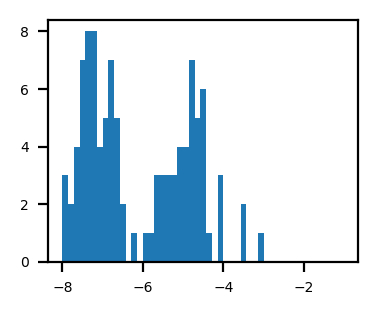

In [338]:
vals = (torch.mean(baseline_sampled_mesor,dim=0)[0,:] / np.log(10)).numpy()
fig,ax=plt.subplots(figsize=(2,1.6),dpi=200)
plt.hist(vals,bins=np.linspace(-8,-1,50))
plt.show()




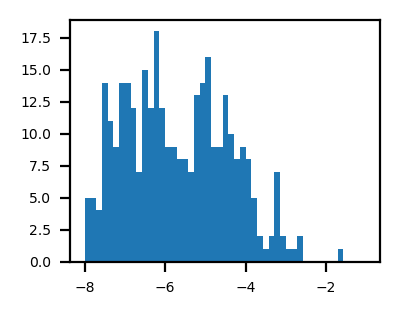

In [331]:
vals = (torch.mean(baseline_sampled_mesor,dim=0)[0,:] / np.log(10)).numpy()
fig,ax=plt.subplots(figsize=(2,1.6),dpi=200)
plt.hist(vals,bins=np.linspace(-8,-1,50))
plt.show()





In [266]:
# ** run umap **

import umap


n_components = 2
n_neighbors = 300
min_dist = 0.1

metric = 'euclidean'
umap_embedding = umap.UMAP(n_neighbors=n_neighbors,
                  metric=metric, n_components = n_components).fit_transform(coded_X)





/Users/mingyaolab/opt/anaconda3/envs/misalignment/lib/python3.10/site-packages/umap/umap_.py:2344: UserWarning: n_neighbors is larger than the dataset size; truncating to X.shape[0] - 1
  warn(


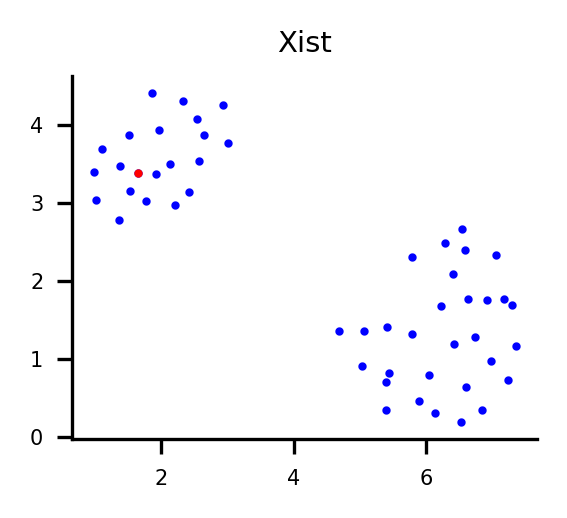

In [267]:

for gene in ['Oct4', 'Klf4', 'Cdk1', 'Cdk2ap1', 'Cdkl5', 'Cdkn1a', 'Cdkn2a', 'Cdkn2b', 'Cdkn3'] + ['Hspa1a', 'Hspa1b', 'Dbp', 'Nr1d1', 'Nr1d1', 'Nfil3', 'Arntl', 'Xist']:
    if gene not in de_genes:
        continue
    gene_index = np.where(np.array(de_genes) == gene)[0].item()
    
    
    fig,ax = plt.subplots(figsize=(2,1.6),dpi=300)
    plt.scatter(umap_embedding[:,0],umap_embedding[:,1],s=1,c='b')
    plt.scatter(umap_embedding[gene_index,0],umap_embedding[gene_index,1],s=1,c='r')
    plt.title(gene)
    sns.despine()
    plt.show()
    
    
    


In [258]:
cluster

0